# Simple Linear Regression Implementation

This notebook demonstrates a simple linear regression model implemented from scratch in Python.  
We use gradient descent to optimize the parameters and visualize the results with Matplotlib.

---

## 1. Importing Libraries
We start by importing the necessary libraries:
- **pandas** for handling datasets
- **matplotlib** for visualization
- **random** for initializing weights and bias randomly
- **sklearn** for comparing our model with an existing one


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.linear_model import LinearRegression
import numpy as np


## 2. Defining the Model Class
We create a class `SimpleLinearRegression` that contains:
- Initialization of parameters (`w_now` and `b_now`)
- A method for **gradient descent** to update weights and bias
- A **fit** method to train the model over multiple epochs
- A **predict** method to make predictions on new data


## 3. Gradient Descent
The `gradient_descent` method calculates the gradients of the loss function with respect to weight and bias.  
It then updates the parameters using the learning rate.  
This is the core optimization step of linear regression.


## 4. Training the Model
The `fit` method runs gradient descent for a given number of epochs.  
Every 50 epochs, we print the current epoch to track progress.  
At the end, we obtain the optimized values of weight and bias.


## 5. Making Predictions
The `predict` method applies the learned linear equation:


\[
y = w * x + b
\]


to estimate the output for a given input value.


In [10]:
class SimpleLinearRegression:
    def __init__(self):
        self.w_now = random.random() # Initializing current weight and bias randomly
        self.b_now = random.random()

    def gradient_descent(self, x_train, y_train, learning_rate):
        w_gradient = 0
        b_gradient = 0
        n = len(x_train)
        for i in range(n):
            w_gradient += -(2/n) * (y_train[i] - (self.w_now * x_train[i] + self.b_now)) * x_train[i]
            b_gradient += -(2/n) * (y_train[i] - (self.w_now * x_train[i] + self.b_now))
        w = self.w_now - learning_rate * w_gradient
        b = self.b_now - learning_rate * b_gradient
        return w, b
    
    def fit(self, x_train, y_train, learning_rate, epochs):
        for i in range(epochs):
            if (i % 50 == 0):
                print(f"epoch: {i}")
            self.w_now, self.b_now = self.gradient_descent(x_train, y_train, learning_rate)
        return self.w_now, self.b_now
    
    def predict(self, value):
        return self.w_now * value + self.b_now


## 6. Loading the Dataset
We load the dataset `Salary_Data.csv` using pandas.  
This dataset contains two columns:
- **YearsExperience** (independent variable)
- **Salary** (dependent variable)


In [11]:
data = pd.read_csv("C:/Users/pc/machine-learning-algorithms/datasets/Salary_Data.csv")
x_train = data['YearsExperience']
y_train = data['Salary']

## 7. Training Parameters
We set:
- **Learning rate (L)** = 0.0001  
- **Epochs** = 30,000  
These values control the speed and duration of training.


In [12]:
L = 0.0001
epochs = 30000

## 8. Visualizing the Results
Finally, we plot:
- A scatter plot of the original data (YearsExperience vs Salary)
- The regression line predicted by our model  
This visualization shows how well the model fits the data.


epoch: 0
epoch: 50
epoch: 100
epoch: 150
epoch: 200
epoch: 250
epoch: 300
epoch: 350
epoch: 400
epoch: 450
epoch: 500
epoch: 550
epoch: 600
epoch: 650
epoch: 700
epoch: 750
epoch: 800
epoch: 850
epoch: 900
epoch: 950
epoch: 1000
epoch: 1050
epoch: 1100
epoch: 1150
epoch: 1200
epoch: 1250
epoch: 1300
epoch: 1350
epoch: 1400
epoch: 1450
epoch: 1500
epoch: 1550
epoch: 1600
epoch: 1650
epoch: 1700
epoch: 1750
epoch: 1800
epoch: 1850
epoch: 1900
epoch: 1950
epoch: 2000
epoch: 2050
epoch: 2100
epoch: 2150
epoch: 2200
epoch: 2250
epoch: 2300
epoch: 2350
epoch: 2400
epoch: 2450
epoch: 2500
epoch: 2550
epoch: 2600
epoch: 2650
epoch: 2700
epoch: 2750
epoch: 2800
epoch: 2850
epoch: 2900
epoch: 2950
epoch: 3000
epoch: 3050
epoch: 3100
epoch: 3150
epoch: 3200
epoch: 3250
epoch: 3300
epoch: 3350
epoch: 3400
epoch: 3450
epoch: 3500
epoch: 3550
epoch: 3600
epoch: 3650
epoch: 3700
epoch: 3750
epoch: 3800
epoch: 3850
epoch: 3900
epoch: 3950
epoch: 4000
epoch: 4050
epoch: 4100
epoch: 4150
epoch: 4200
epo

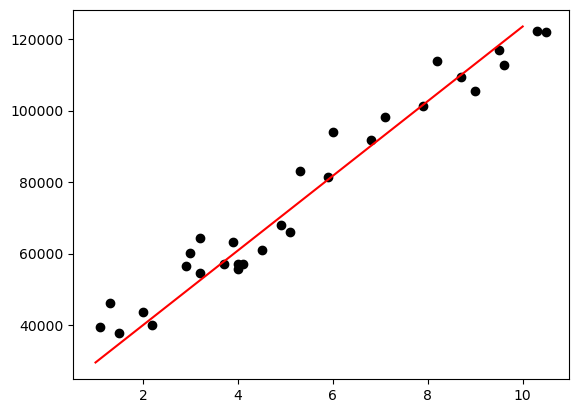

In [13]:
lr = SimpleLinearRegression()
w, b = lr.fit(x_train, y_train, L, epochs)

plt.scatter(data.YearsExperience, data.Salary, color="black")
plt.plot(list(range(1, 11)), [lr.predict(x) for x in range(1, 11)], color="red")
plt.show()

## 9. Comparison with Scikit-learn Linear Regression

To validate our custom implementation, we compare it with the built-in `LinearRegression` model from scikit-learn.  
This allows us to check whether our gradient descent approach produces similar results to a well-tested library.


Custom model parameters: w = 10445.310011948992 , b = 19084.816293820964
Sklearn model parameters: w = 9449.962321455074 , b = 25792.20019866871


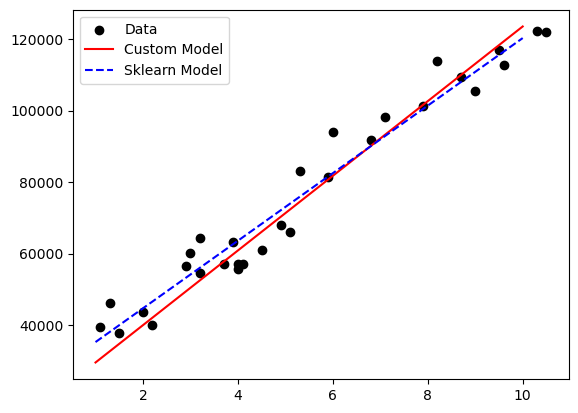

In [14]:
# Reshape x_train for sklearn (expects 2D array)
X = np.array(x_train).reshape(-1, 1)
y = np.array(y_train)

# Train sklearn model
sk_model = LinearRegression()
sk_model.fit(X, y)

# Extract parameters
w_sk = sk_model.coef_[0]
b_sk = sk_model.intercept_

print("Custom model parameters: w =", w, ", b =", b)
print("Sklearn model parameters: w =", w_sk, ", b =", b_sk)

# Plot comparison
plt.scatter(data.YearsExperience, data.Salary, color="black", label="Data")
plt.plot(list(range(1, 11)), [lr.predict(x) for x in range(1, 11)], color="red", label="Custom Model")
plt.plot(list(range(1, 11)), [sk_model.predict([[x]])[0] for x in range(1, 11)], color="blue", linestyle="--", label="Sklearn Model")
plt.legend()
plt.show()
